# 08. RQ3 disability strand -- forward forecasting (Year 9-16)


## 0. Setup

In [35]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 2026
ALR_EPSILON = 1e-6

FORECAST_START_YEAR = 8   # last observed year, forecasting begins at 9
FORECAST_HORIZON = 8      # Year 9 .. Year 16
YEAR_REF = 8               # keep the same time_trend scale used in training

DISABILITY_DATA_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed")
OUTPUT_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs")
FORECAST_DIR = OUTPUT_DIR / 'forecast_year9_16'
FORECAST_DIR.mkdir(parents=True, exist_ok=True)

best_params_df = pd.read_csv(OUTPUT_DIR / 'best_hyperparameters.csv')

summary = pd.read_csv(OUTPUT_DIR / 'summary_full.csv')

with open(OUTPUT_DIR / 'fitted_models.pkl', 'rb') as f:
    fitted_models = pickle.load(f)

print('tasks available in summary:', summary['task'].unique().tolist())
print('fitted models available:', list(fitted_models.keys()))

tasks available in summary: ['age_activity_level', 'age_days10p60gr', 'age_months12', 'age_overall_level', 'disability_activity_level', 'disability_days10p60gr', 'disability_months12', 'disability_overall_level']
fitted models available: ['age_overall__Ridge Regression', 'age_overall__Random Forest', 'age_overall__Gradient Boosting', 'dis_overall__Ridge Regression', 'dis_overall__Random Forest', 'dis_overall__Gradient Boosting', 'dis_level__Ridge Regression', 'dis_level__Random Forest', 'dis_level__Gradient Boosting', 'months12__Ridge Regression', 'months12__Random Forest', 'months12__Gradient Boosting', 'days__Ridge Regression', 'days__Random Forest', 'days__Gradient Boosting', 'age_months12__Ridge Regression', 'age_months12__Random Forest', 'age_months12__Gradient Boosting', 'age_days__Ridge Regression', 'age_days__Random Forest', 'age_days__Gradient Boosting', 'age_level__Ridge Regression', 'age_level__Random Forest', 'age_level__Gradient Boosting']


## 1. Shared forecasting functions


In [36]:
def alr_to_shares(values):
    values = np.clip(np.asarray(values, dtype=float), -30, 30)
    exponent = np.exp(values)
    denominator = 1 + exponent.sum(axis=1, keepdims=True)
    return np.column_stack([exponent / denominator, 1 / denominator])


def shares_to_alr(shares):
    clipped = np.clip(np.asarray(shares, dtype=float), ALR_EPSILON, 1)
    clipped = clipped / clipped.sum(axis=1, keepdims=True)
    return np.log(clipped[:, :2] / clipped[:, [2]])


def select_best_model(summary_df, task_name, metric_col):
    """只在validation split里选,不排除Naive baseline。"""
    subset = summary_df[
        (summary_df['task'] == task_name) &
        (summary_df['split'] == 'validation')
    ]
    best_row = subset.loc[subset[metric_col].idxmin()]
    return best_row['model']

In [37]:
def add_lag_features(frame, panel_keys, value_cols, lags=(1,), rolling_window=None, covid_years=(5, 6)):
    prepared = frame.sort_values(panel_keys + ['year']).reset_index(drop=True)
    grouped = prepared.groupby(panel_keys, sort=False)
    for column in value_cols:
        for lag in lags:
            prepared[f'{column}_lag{lag}'] = grouped[column].shift(lag)
        if rolling_window:
            prepared[f'{column}_roll{rolling_window}'] = grouped[column].transform(
                lambda s: s.shift(1).rolling(rolling_window, min_periods=1).mean()
            )
    prepared['time_trend'] = prepared['year'] / prepared['year'].max()
    prepared['is_covid_year'] = prepared['year'].isin(covid_years).astype(int)
    return prepared


def build_model(model_name, parameters, numeric_features, categorical_features, multi_output):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if model_name == 'Ridge Regression':
        numeric_steps.append(('scale', StandardScaler()))
    preprocess = ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ])
    if model_name == 'Ridge Regression':
        estimator = Ridge(**parameters)
    elif model_name == 'Random Forest':
        estimator = RandomForestRegressor(**parameters, random_state=RANDOM_STATE, n_jobs=-1)
    else:
        base = GradientBoostingRegressor(**parameters, random_state=RANDOM_STATE, loss='huber')
        estimator = MultiOutputRegressor(base) if multi_output else base
    return Pipeline([('preprocess', preprocess), ('model', estimator)])


PARAMETER_TASK_NAME_MAP = {
    'age_overall_level': 'age_overall',
    'disability_overall_level': 'dis_overall',
    'age_activity_level': 'age_level',
    'disability_activity_level': 'dis_level',
    'age_months12': 'age_months12',
    'disability_months12': 'months12',
    'age_days10p60gr': 'age_days',
    'disability_days10p60gr': 'days'
}


def get_best_params(task_name, model_name):

    if model_name == 'Naive baseline':
        return {}

    if task_name not in PARAMETER_TASK_NAME_MAP:
        raise KeyError(
            f'No parameter-task mapping has been defined for {task_name}. '
            f'The forecast has been stopped to prevent the model from using '
            f'unchecked default parameters.'
        )

    parameter_task_name = PARAMETER_TASK_NAME_MAP[task_name]

    matching_rows = best_params_df[
        (best_params_df['task'] == parameter_task_name) &
        (best_params_df['model'] == model_name)
    ].copy()

    if matching_rows.empty:
        raise ValueError(
            f'No tuned parameters were found for forecast task {task_name}, '
            f'parameter task {parameter_task_name}, and model {model_name}. '
            f'The forecast has been stopped instead of silently using '
            f'scikit-learn default parameters.'
        )

    parameters = (
        matching_rows
        .iloc[0]
        .drop(labels=['task', 'model'])
        .dropna()
        .to_dict()
    )

    integer_parameters = [
        'n_estimators',
        'max_depth',
        'min_samples_leaf'
    ]

    for parameter_name in integer_parameters:
        if parameter_name in parameters:
            parameters[parameter_name] = int(parameters[parameter_name])

    expected_parameters = {
        'Ridge Regression': {
            'alpha'
        },
        'Random Forest': {
            'n_estimators',
            'max_depth',
            'min_samples_leaf',
            'max_features'
        },
        'Gradient Boosting': {
            'n_estimators',
            'learning_rate',
            'max_depth',
            'min_samples_leaf'
        }
    }

    if model_name not in expected_parameters:
        raise ValueError(
            f'Unsupported model name {model_name} was supplied for '
            f'forecast task {task_name}.'
        )

    missing_parameters = (
        expected_parameters[model_name] -
        set(parameters.keys())
    )

    if missing_parameters:
        raise ValueError(
            f'Tuned parameters are incomplete for forecast task {task_name} '
            f'and model {model_name}. Missing parameters are '
            f'{sorted(missing_parameters)}.'
        )

    print(
        f'Forecast task: {task_name} | '
        f'parameter task: {parameter_task_name} | '
        f'model: {model_name} | '
        f'tuned parameters: {parameters}'
    )

    return parameters

In [38]:
EXPECTED_PARAMETER_TASKS = {
    'age_overall',
    'dis_overall',
    'age_level',
    'dis_level',
    'age_months12',
    'months12',
    'age_days',
    'days'
}

AVAILABLE_PARAMETER_TASKS = set(
    best_params_df['task']
    .dropna()
    .astype(str)
    .unique()
)

MISSING_PARAMETER_TASKS = (
    EXPECTED_PARAMETER_TASKS -
    AVAILABLE_PARAMETER_TASKS
)

if MISSING_PARAMETER_TASKS:
    raise ValueError(
        f'The hyperparameter file is missing the following tasks: '
        f'{sorted(MISSING_PARAMETER_TASKS)}'
    )

print(
    'Hyperparameter task-name check passed. '
    'All eight parameter-task names are available.'
)

Hyperparameter task-name check passed. All eight parameter-task names are available.


In [39]:
def refit_production_model(raw_frame, panel_keys, target_cols, weight_col,
                            feature_level, model_name, best_params, is_composition):
    if feature_level == 'overall':
        prepared = add_lag_features(raw_frame, panel_keys, target_cols, lags=(1, 2))
        extra_cols = [f'{c}_lag2' for c in target_cols]
    else:
        prepared = add_lag_features(raw_frame, panel_keys, target_cols, lags=(1,), rolling_window=2)
        extra_cols = [f'{c}_roll2' for c in target_cols]

    lag1_cols = [f'{c}_lag1' for c in target_cols]
    numeric = lag1_cols + extra_cols + ['time_trend', 'is_covid_year']
    categorical = list(panel_keys)

    train_all = prepared.dropna(subset=target_cols + [weight_col] + lag1_cols + extra_cols).copy()

    if model_name == 'Ridge Regression':
        train_all, interaction_cols = add_interaction_terms(train_all, panel_keys[1])
        numeric = numeric + interaction_cols

    model = build_model(model_name, best_params, numeric, categorical, multi_output=is_composition)
    weights = train_all[weight_col].to_numpy()
    y = shares_to_alr(train_all[target_cols]) if is_composition else train_all[target_cols[0]]

    model.fit(train_all[numeric + categorical], y, model__sample_weight=weights)
    return model

In [40]:
def build_forecast_seed(raw_frame, panel_keys, target_cols, require_full_history,
                         start_year=FORECAST_START_YEAR):
    two_years = raw_frame[
        raw_frame['year'].isin([start_year - 1, start_year])
    ].dropna(subset=target_cols)

    year_counts = two_years.groupby(panel_keys)['year'].nunique()
    full_history_keys = set(year_counts[year_counts == 2].index)
    partial_keys = set(year_counts[year_counts == 1].index)
    has_year8 = set(
        two_years[two_years['year'] == start_year].set_index(panel_keys).index
    )
    year8_only_keys = partial_keys & has_year8
    dropped_no_year8 = partial_keys - has_year8

    if require_full_history:
        keep_keys = full_history_keys
        dropped_no_year7 = year8_only_keys
    else:
        keep_keys = full_history_keys | year8_only_keys
        dropped_no_year7 = set()

    seed = two_years[two_years.set_index(panel_keys).index.isin(keep_keys)].copy()
    diagnostic = pd.DataFrame([{
        'panels_full_2yr_history': len(full_history_keys & keep_keys),
        'panels_year8_only_used': len(year8_only_keys & keep_keys),
        'panels_dropped_no_year7': len(dropped_no_year7),
        'panels_dropped_no_year8': len(dropped_no_year8),
    }])
    return seed, diagnostic

In [41]:
def add_interaction_terms(frame, group_col, time_col='time_trend'):
    dummies = pd.get_dummies(frame[group_col], prefix=f'{group_col}_x_time')
    interaction_cols = list(dummies.columns)
    frame = frame.copy()
    frame[interaction_cols] = dummies.mul(frame[time_col], axis=0)
    return frame, interaction_cols


def forecast_composition_task(fitted_model, seed_two_years, panel_keys, target_cols,
                               feature_level, needs_interaction,
                               start_year=FORECAST_START_YEAR,
                               horizon=FORECAST_HORIZON, year_ref=YEAR_REF):
    lag1_cols = [f'{c}_lag1' for c in target_cols]
    extra_cols = ([f'{c}_lag2' for c in target_cols] if feature_level == 'overall'
                  else [f'{c}_roll2' for c in target_cols])

    history = {}
    for key, grp in seed_two_years.sort_values('year').groupby(panel_keys):
        history[key] = grp[target_cols].to_numpy().tolist()
    keys = list(history.keys())
    records = []

    for step in range(1, horizon + 1):
        forecast_year = start_year + step
        rows = []
        for key in keys:
            vals = history[key]
            last = vals[-1]
            prev = vals[-2] if len(vals) >= 2 else None
            row = dict(zip(panel_keys, key))
            for i, c in enumerate(target_cols):
                row[f'{c}_lag1'] = last[i]
                if feature_level == 'overall':
                    row[f'{c}_lag2'] = prev[i] if prev is not None else last[i]
                else:
                    row[f'{c}_roll2'] = (last[i] + prev[i]) / 2.0 if prev is not None else last[i]
            row['time_trend'] = forecast_year / year_ref
            row['is_covid_year'] = 0
            rows.append(row)
        features = pd.DataFrame(rows)

        numeric = lag1_cols + extra_cols + ['time_trend', 'is_covid_year']
        model_input = features
        cols_needed = numeric + panel_keys
        if needs_interaction:
            model_input, interaction_cols = add_interaction_terms(features, panel_keys[1])
            cols_needed = numeric + interaction_cols + panel_keys

        if fitted_model is None:
            predicted_shares = features[lag1_cols].to_numpy()
        else:
            predicted_alr = fitted_model.predict(model_input[cols_needed])
            predicted_shares = alr_to_shares(predicted_alr)

        step_result = features[panel_keys].copy()
        step_result['year'] = forecast_year
        for i, c in enumerate(target_cols):
            step_result[c] = predicted_shares[:, i]
        records.append(step_result)

        for idx, key in enumerate(keys):
            new_val = predicted_shares[idx].tolist()
            history[key] = [history[key][-1], new_val] if len(history[key]) >= 1 else [new_val]

    return pd.concat(records, ignore_index=True)

In [42]:
def forecast_single_rate_task(fitted_model, seed_two_years, panel_keys, target_col,
                               feature_level, needs_interaction,
                               start_year=FORECAST_START_YEAR,
                               horizon=FORECAST_HORIZON, year_ref=YEAR_REF):
    lag1_col = f'{target_col}_lag1'
    extra_col = f'{target_col}_lag2' if feature_level == 'overall' else f'{target_col}_roll2'

    history = {}
    for key, grp in seed_two_years.sort_values('year').groupby(panel_keys):
        history[key] = grp[target_col].to_numpy().tolist()
    keys = list(history.keys())
    records = []

    for step in range(1, horizon + 1):
        forecast_year = start_year + step
        rows = []
        for key in keys:
            vals = history[key]
            last = vals[-1]
            prev = vals[-2] if len(vals) >= 2 else None
            row = dict(zip(panel_keys, key))
            row[lag1_col] = last
            if feature_level == 'overall':
                row[extra_col] = prev if prev is not None else last
            else:
                row[extra_col] = (last + prev) / 2.0 if prev is not None else last
            row['time_trend'] = forecast_year / year_ref
            row['is_covid_year'] = 0
            rows.append(row)
        features = pd.DataFrame(rows)

        numeric = [lag1_col, extra_col, 'time_trend', 'is_covid_year']
        model_input = features
        cols_needed = numeric + panel_keys
        if needs_interaction:
            model_input, interaction_cols = add_interaction_terms(features, panel_keys[1])
            cols_needed = numeric + interaction_cols + panel_keys

        if fitted_model is None:
            predicted = features[lag1_col].to_numpy()
        else:
            predicted = np.clip(fitted_model.predict(model_input[cols_needed]), 0, 1)

        step_result = features[panel_keys].copy()
        step_result['year'] = forecast_year
        step_result[target_col] = predicted
        records.append(step_result)

        for idx, key in enumerate(keys):
            new_val = predicted[idx]
            history[key] = [history[key][-1], new_val] if len(history[key]) >= 1 else [new_val]

    return pd.concat(records, ignore_index=True)

## 2. Forecast: disability overall activity level

Three-tier composition (inactive / fairly_active / active) at the
borough x disability_group level.

In [43]:
dis_overall_raw = pd.read_csv(DISABILITY_DATA_DIR / 'RQ3_borough_disability_overall_all_years.csv')
dis_overall_raw['LA_2023'] = dis_overall_raw['LA_2023'].astype('Int64').astype(str)

dis_overall_targets = ['inactive_rate', 'fairly_active_rate', 'active_rate']
dis_overall_panel_keys = ['LA_2023', 'disability_group']

dis_overall_best_model_name = select_best_model(summary, 'disability_overall_level', 'total_variation')
print('best model, disability overall level:', dis_overall_best_model_name)

if dis_overall_best_model_name == 'Naive baseline':
    dis_overall_production_model = None
else:
    dis_overall_params = get_best_params('disability_overall_level', dis_overall_best_model_name)
    dis_overall_production_model = refit_production_model(
        dis_overall_raw, dis_overall_panel_keys, dis_overall_targets, 'weighted_n',
        feature_level='overall', model_name=dis_overall_best_model_name,
        best_params=dis_overall_params, is_composition=True,
    )
dis_overall_needs_interaction = (dis_overall_best_model_name == 'Ridge Regression')

dis_overall_seed, dis_overall_seed_diag = build_forecast_seed(
    dis_overall_raw, dis_overall_panel_keys, dis_overall_targets, require_full_history=True,
)
print('seed completeness, disability overall level:')
print(dis_overall_seed_diag)

dis_overall_forecast = forecast_composition_task(
    dis_overall_production_model, dis_overall_seed,
    panel_keys=dis_overall_panel_keys, target_cols=dis_overall_targets,
    feature_level='overall', needs_interaction=dis_overall_needs_interaction,
)
dis_overall_forecast_naive = forecast_composition_task(
    None, dis_overall_seed,
    panel_keys=dis_overall_panel_keys, target_cols=dis_overall_targets,
    feature_level='overall', needs_interaction=False,
)
dis_overall_forecast.head()

best model, disability overall level: Gradient Boosting
Forecast task: disability_overall_level | parameter task: dis_overall | model: Gradient Boosting | tuned parameters: {'n_estimators': 120, 'max_depth': 2, 'min_samples_leaf': 15, 'learning_rate': 0.05}
seed completeness, disability overall level:
   panels_full_2yr_history  panels_year8_only_used  panels_dropped_no_year7  \
0                      510                       0                        2   

   panels_dropped_no_year8  
0                        0  


,LA_2023,disability_group,year,inactive_rate,fairly_active_rate,active_rate
0,107,disty1,9,0.413501,0.106271,0.480228
1,107,disty10,9,0.388865,0.077464,0.533671
2,107,disty11,9,0.442974,0.066250,0.490776
3,107,disty12,9,0.418276,0.098550,0.483173
4,107,disty13,9,0.359665,0.051637,0.588698


## 3. Forecast: disability activity-specific level

Same three-tier composition, but at the borough x disability_group x activity
granularity.

In [44]:
dis_level_raw = pd.read_csv(DISABILITY_DATA_DIR / 'RQ3_borough_disability_MEMS7GR_all_years.csv')
dis_level_raw['LA_2023'] = dis_level_raw['LA_2023'].astype('Int64').astype(str)

dis_level_targets = ['inactive_rate', 'fairly_active_rate', 'active_rate']
dis_level_panel_keys = ['LA_2023', 'disability_group', 'activity']

dis_level_best_model_name = select_best_model(summary, 'disability_activity_level', 'total_variation')
print('best model, disability activity level:', dis_level_best_model_name)

if dis_level_best_model_name == 'Naive baseline':
    dis_level_production_model = None
else:
    dis_level_params = get_best_params('disability_activity_level', dis_level_best_model_name)
    dis_level_production_model = refit_production_model(
        dis_level_raw, dis_level_panel_keys, dis_level_targets, 'weighted_n',
        feature_level='activity', model_name=dis_level_best_model_name,
        best_params=dis_level_params, is_composition=True,
    )
dis_level_needs_interaction = (dis_level_best_model_name == 'Ridge Regression')

dis_level_seed, dis_level_seed_diag = build_forecast_seed(
    dis_level_raw, dis_level_panel_keys, dis_level_targets, require_full_history=False,
)
print('seed completeness, disability activity level:')
print(dis_level_seed_diag)

dis_level_forecast = forecast_composition_task(
    dis_level_production_model, dis_level_seed,
    panel_keys=dis_level_panel_keys, target_cols=dis_level_targets,
    feature_level='activity', needs_interaction=dis_level_needs_interaction,
)
dis_level_forecast_naive = forecast_composition_task(
    None, dis_level_seed,
    panel_keys=dis_level_panel_keys, target_cols=dis_level_targets,
    feature_level='activity', needs_interaction=False,
)
dis_level_forecast.head()

best model, disability activity level: Gradient Boosting
Forecast task: disability_activity_level | parameter task: dis_level | model: Gradient Boosting | tuned parameters: {'n_estimators': 120, 'max_depth': 2, 'min_samples_leaf': 15, 'learning_rate': 0.05}
seed completeness, disability activity level:
   panels_full_2yr_history  panels_year8_only_used  panels_dropped_no_year7  \
0                    62392                     725                        0   

   panels_dropped_no_year8  
0                      318  


,LA_2023,disability_group,activity,year,inactive_rate,fairly_active_rate,active_rate
0,107,disty1,ABSEILING_H03,9,0.999998,0.000001,0.000001
1,107,disty1,ACTTRAV_C03,9,0.743969,0.102978,0.153053
2,107,disty1,AIKIDO_S04,9,0.999998,0.000001,0.000001
3,107,disty1,AIRGUN_S08,9,0.999998,0.000001,0.000001
4,107,disty1,ARCHERY_J01,9,0.999998,0.000001,0.000001


## 4. Forecast: MONTHS_12 and DAYS10P60GR participation rate

The two binary participation measures at the borough x disability_group x
activity level, modelled and forecast independently.

In [45]:
dis_dm_raw = pd.read_csv(DISABILITY_DATA_DIR / 'RQ3_borough_disability_days_months_all_years.csv')
dis_dm_raw['LA_2023'] = dis_dm_raw['LA_2023'].astype('Int64').astype(str)
dis_dm_panel_keys = ['LA_2023', 'disability_group', 'activity']

months12_best_model_name = select_best_model(summary, 'disability_months12', 'participation_MONTHS_12_mae')
print('best model, MONTHS_12:', months12_best_model_name)

if months12_best_model_name == 'Naive baseline':
    months12_production_model = None
else:
    months12_params = get_best_params('disability_months12', months12_best_model_name)
    months12_production_model = refit_production_model(
        dis_dm_raw, dis_dm_panel_keys, ['participation_MONTHS_12'], 'weighted_n_MONTHS_12',
        feature_level='activity', model_name=months12_best_model_name,
        best_params=months12_params, is_composition=False,
    )
months12_needs_interaction = (months12_best_model_name == 'Ridge Regression')

months12_seed, months12_seed_diag = build_forecast_seed(
    dis_dm_raw, dis_dm_panel_keys, ['participation_MONTHS_12'], require_full_history=False,
)
print('seed completeness, MONTHS_12:')
print(months12_seed_diag)

months12_forecast = forecast_single_rate_task(
    months12_production_model, months12_seed,
    panel_keys=dis_dm_panel_keys, target_col='participation_MONTHS_12',
    feature_level='activity', needs_interaction=months12_needs_interaction,
)
months12_forecast_naive = forecast_single_rate_task(
    None, months12_seed,
    panel_keys=dis_dm_panel_keys, target_col='participation_MONTHS_12',
    feature_level='activity', needs_interaction=False,
)

days_best_model_name = select_best_model(summary, 'disability_days10p60gr', 'participation_DAYS10P60GR_mae')
print('best model, DAYS10P60GR:', days_best_model_name)

if days_best_model_name == 'Naive baseline':
    days_production_model = None
else:
    days_params = get_best_params('disability_days10p60gr', days_best_model_name)
    days_production_model = refit_production_model(
        dis_dm_raw, dis_dm_panel_keys, ['participation_DAYS10P60GR'], 'weighted_n_DAYS10P60GR',
        feature_level='activity', model_name=days_best_model_name,
        best_params=days_params, is_composition=False,
    )
days_needs_interaction = (days_best_model_name == 'Ridge Regression')

days_seed, days_seed_diag = build_forecast_seed(
    dis_dm_raw, dis_dm_panel_keys, ['participation_DAYS10P60GR'], require_full_history=False,
)
print('seed completeness, DAYS10P60GR:')
print(days_seed_diag)

days_forecast = forecast_single_rate_task(
    days_production_model, days_seed,
    panel_keys=dis_dm_panel_keys, target_col='participation_DAYS10P60GR',
    feature_level='activity', needs_interaction=days_needs_interaction,
)
days_forecast_naive = forecast_single_rate_task(
    None, days_seed,
    panel_keys=dis_dm_panel_keys, target_col='participation_DAYS10P60GR',
    feature_level='activity', needs_interaction=False,
)

months12_forecast.head()

best model, MONTHS_12: Gradient Boosting
Forecast task: disability_months12 | parameter task: months12 | model: Gradient Boosting | tuned parameters: {'n_estimators': 120, 'max_depth': 2, 'min_samples_leaf': 15, 'learning_rate': 0.05}
seed completeness, MONTHS_12:
   panels_full_2yr_history  panels_year8_only_used  panels_dropped_no_year7  \
0                    62392                     725                        0   

   panels_dropped_no_year8  
0                      318  
best model, DAYS10P60GR: Gradient Boosting
Forecast task: disability_days10p60gr | parameter task: days | model: Gradient Boosting | tuned parameters: {'n_estimators': 120, 'max_depth': 2, 'min_samples_leaf': 15, 'learning_rate': 0.05}
seed completeness, DAYS10P60GR:
   panels_full_2yr_history  panels_year8_only_used  panels_dropped_no_year7  \
0                    62392                     725                        0   

   panels_dropped_no_year8  
0                      318  


,LA_2023,disability_group,activity,year,participation_MONTHS_12
0,107,disty1,ABSEILING_H03,9,0.003149
1,107,disty1,ACTTRAV_C03,9,0.530949
2,107,disty1,AIKIDO_S04,9,0.003149
3,107,disty1,AIRGUN_S08,9,0.014689
4,107,disty1,ARCHERY_J01,9,0.008875


## 5. Top two predicted activities and ranking margin, by forecast year

In [46]:
def top_two_activities_by_year(forecast_frame, id_cols, activity_col, value_col):
    ranked = forecast_frame.sort_values(
        id_cols + [value_col, activity_col],
        ascending=[True] * len(id_cols) + [False, True]
    ).copy()

    ranked["activity_rank"] = ranked.groupby(id_cols).cumcount() + 1
    ranked = ranked[ranked["activity_rank"] <= 2].copy()

    top_activity = ranked[ranked["activity_rank"] == 1][
        id_cols + [activity_col, value_col]
    ].copy()

    second_activity = ranked[ranked["activity_rank"] == 2][
        id_cols + [activity_col, value_col]
    ].copy()

    second_activity = second_activity.rename(columns={
        activity_col: "second_activity",
        value_col: "second_participation_MONTHS_12"
    })

    result = top_activity.merge(
        second_activity,
        on=id_cols,
        how="left",
        validate="one_to_one"
    )

    result["ranking_margin"] = (
        result[value_col] - result["second_participation_MONTHS_12"]
    )

    result["top_two_tied"] = np.isclose(
        result[value_col],
        result["second_participation_MONTHS_12"],
        atol=1e-10
    )

    return result


top_activity_forecast = top_two_activities_by_year(
    months12_forecast,
    id_cols=["year", "LA_2023", "disability_group"],
    activity_col="activity",
    value_col="participation_MONTHS_12"
)

assert top_activity_forecast.duplicated(
    subset=["year", "LA_2023", "disability_group"]
).sum() == 0

assert top_activity_forecast["second_activity"].notna().all()
assert (top_activity_forecast["ranking_margin"] >= -1e-12).all()

top_activity_forecast.head(10)

,year,LA_2023,disability_group,activity,participation_MONTHS_12,second_activity,second_participation_MONTHS_12,ranking_margin,top_two_tied
0,9,107,disty1,ACTTRAV_C03,0.530949,WALKTRAV_B02,0.514952,0.015997,False
1,9,107,disty10,ACTTRAV_C03,0.381229,WALKTRAV_B02,0.369270,0.011959,False
2,9,107,disty11,ACTTRAV_C03,0.353310,WALKTRAV_B02,0.341351,0.011959,False
3,9,107,disty12,ACTTRAV_C03,0.542017,WALKTRAV_B02,0.530059,0.011959,False
4,9,107,disty13,ACTTRAV_C03,0.599740,WALKTRAV_B02,0.587781,0.011959,False
5,9,107,disty2,ACTTRAV_C03,0.530949,WALKTRAV_B02,0.518990,0.011959,False
6,9,107,disty3,ACTTRAV_C03,0.412368,GARD_B08,0.405151,0.007217,False
7,9,107,disty4,ACTTRAV_C03,0.443707,WALKTRAV_B02,0.431748,0.011959,False
8,9,107,disty5,ACTTRAV_C03,0.608120,WALKTRAV_B02,0.596162,0.011959,False
9,9,107,disty6,GARD_B08,0.331608,ACTTRAV_C03,0.303759,0.027849,False


## 6. Historical sample-size warnings for future forecasts

In [47]:
def historical_sample_diagnostics(frame, keys, target_col, n_col):
    expected_years = frame["year"].nunique()
    valid = frame.dropna(subset=[target_col, n_col]).copy()
    valid["historical_small_cell"] = valid[n_col] < 30

    result = valid.groupby(keys).agg(
        historical_years_available=(target_col, "size"),
        historical_small_cell_years=("historical_small_cell", "sum"),
        historical_median_n=(n_col, "median"),
        historical_min_n=(n_col, "min")
    ).reset_index()

    result["historical_small_cell_rate"] = result["historical_small_cell_years"] / result["historical_years_available"]
    result["historical_small_cell_majority"] = result["historical_small_cell_rate"] >= 0.5
    result["historical_incomplete_outcome_history"] = result["historical_years_available"] < expected_years
    result["historical_reliability_warning"] = result["historical_small_cell_majority"] | result["historical_incomplete_outcome_history"]
    return result

dis_overall_reliability = historical_sample_diagnostics(
    dis_overall_raw, dis_overall_panel_keys, "active_rate", "n"
)

dis_level_reliability = historical_sample_diagnostics(
    dis_level_raw, dis_level_panel_keys, "active_rate", "n"
)

months12_reliability = historical_sample_diagnostics(
    dis_dm_raw, dis_dm_panel_keys, "participation_MONTHS_12", "n_MONTHS_12"
)

days_reliability = historical_sample_diagnostics(
    dis_dm_raw, dis_dm_panel_keys, "participation_DAYS10P60GR", "n_DAYS10P60GR"
)

dis_overall_forecast = dis_overall_forecast.merge(dis_overall_reliability, on=dis_overall_panel_keys, how="left")
dis_overall_forecast_naive = dis_overall_forecast_naive.merge(dis_overall_reliability, on=dis_overall_panel_keys, how="left")
dis_level_forecast = dis_level_forecast.merge(dis_level_reliability, on=dis_level_panel_keys, how="left")
dis_level_forecast_naive = dis_level_forecast_naive.merge(dis_level_reliability, on=dis_level_panel_keys, how="left")
months12_forecast = months12_forecast.merge(months12_reliability, on=dis_dm_panel_keys, how="left")
months12_forecast_naive = months12_forecast_naive.merge(months12_reliability, on=dis_dm_panel_keys, how="left")
days_forecast = days_forecast.merge(days_reliability, on=dis_dm_panel_keys, how="left")
days_forecast_naive = days_forecast_naive.merge(days_reliability, on=dis_dm_panel_keys, how="left")
top_activity_forecast = top_activity_forecast.merge(months12_reliability, on=dis_dm_panel_keys, how="left")

dis_overall_reliability.to_csv(FORECAST_DIR / "historical_sample_diagnostics_disability_overall.csv", index=False)
dis_level_reliability.to_csv(FORECAST_DIR / "historical_sample_diagnostics_disability_activity_level.csv", index=False)
months12_reliability.to_csv(FORECAST_DIR / "historical_sample_diagnostics_disability_months12.csv", index=False)
days_reliability.to_csv(FORECAST_DIR / "historical_sample_diagnostics_disability_days10p60gr.csv", index=False)

print("Overall warning rate:", round(dis_overall_reliability["historical_reliability_warning"].mean(), 3))
print("Activity-level warning rate:", round(dis_level_reliability["historical_reliability_warning"].mean(), 3))
print("MONTHS_12 warning rate:", round(months12_reliability["historical_reliability_warning"].mean(), 3))
print("DAYS10P60GR warning rate:", round(days_reliability["historical_reliability_warning"].mean(), 3))

Overall warning rate: 0.684
Activity-level warning rate: 0.705
MONTHS_12 warning rate: 0.737
DAYS10P60GR warning rate: 0.737


## 7. Sanity checks on forecasts

In [48]:
row_counts = dis_level_forecast.groupby('year').size()
print('rows per forecast year, activity level:')
print(row_counts)

dup_check = {
    'disability_overall_level': dis_overall_forecast.duplicated(subset=dis_overall_panel_keys + ['year']).sum(),
    'disability_activity_level': dis_level_forecast.duplicated(subset=dis_level_panel_keys + ['year']).sum(),
    'months12': months12_forecast.duplicated(subset=dis_dm_panel_keys + ['year']).sum(),
    'days10p60gr': days_forecast.duplicated(subset=dis_dm_panel_keys + ['year']).sum(),
}
print('duplicate panel x year rows (should all be 0):', dup_check)

range_check = {
    'disability_overall_level': (dis_overall_forecast[dis_overall_targets].min().min(),
                                  dis_overall_forecast[dis_overall_targets].max().max()),
    'disability_activity_level': (dis_level_forecast[dis_level_targets].min().min(),
                                   dis_level_forecast[dis_level_targets].max().max()),
    'months12': (months12_forecast['participation_MONTHS_12'].min(),
                 months12_forecast['participation_MONTHS_12'].max()),
    'days10p60gr': (days_forecast['participation_DAYS10P60GR'].min(),
                     days_forecast['participation_DAYS10P60GR'].max()),
}
print('min/max, should stay within 0 to 1:', range_check)

mems7gr_sum_check = (dis_overall_forecast[dis_overall_targets].sum(axis=1) - 1).abs().max()
print('max deviation from summing to 1, overall level:', mems7gr_sum_check)
mems7gr_sum_check_level = (dis_level_forecast[dis_level_targets].sum(axis=1) - 1).abs().max()
print('max deviation from summing to 1, activity level:', mems7gr_sum_check_level)

year9_vs_year8 = dis_overall_raw[dis_overall_raw['year'] == FORECAST_START_YEAR].merge(
    dis_overall_forecast[dis_overall_forecast['year'] == FORECAST_START_YEAR + 1],
    on=dis_overall_panel_keys, suffixes=('_year8', '_year9'),
)
year9_vs_year8['active_rate_jump'] = (
    year9_vs_year8['active_rate_year9'] - year9_vs_year8['active_rate_year8']
).abs()
print('largest active_rate jump from Year 8 to Year 9:')
print(year9_vs_year8.sort_values('active_rate_jump', ascending=False).head(5)[
    dis_overall_panel_keys + ['active_rate_year8', 'active_rate_year9', 'active_rate_jump']
])

top_activity_counts = top_activity_forecast.groupby('year')['activity'].nunique()
print('number of distinct activities selected as top, by forecast year:')
print(top_activity_counts)

comparison = dis_overall_forecast.merge(
    dis_overall_forecast_naive,
    on=['LA_2023', 'disability_group', 'year'],
    suffixes=('_model', '_naive'),
)
comparison['active_rate_gap'] = (comparison['active_rate_model'] - comparison['active_rate_naive']).abs()
gap_by_year = comparison.groupby('year')['active_rate_gap'].mean()
print('mean |model - naive| gap in active_rate, by forecast year:')
print(gap_by_year.round(4))

rows per forecast year, activity level:
year
9     63117
10    63117
11    63117
12    63117
13    63117
14    63117
15    63117
16    63117
dtype: int64
duplicate panel x year rows (should all be 0): {'disability_overall_level': np.int64(0), 'disability_activity_level': np.int64(0), 'months12': np.int64(0), 'days10p60gr': np.int64(0)}
min/max, should stay within 0 to 1: {'disability_overall_level': (0.01096488545847265, 0.8134322462921663), 'disability_activity_level': (3.096367148793773e-07, 0.999998295409203), 'months12': (0.0031487841126525704, 0.8469251349624934), 'days10p60gr': (0.0005889804730771316, 0.5287234086090299)}
max deviation from summing to 1, overall level: 2.220446049250313e-16
max deviation from summing to 1, activity level: 2.220446049250313e-16
largest active_rate jump from Year 8 to Year 9:
    LA_2023 disability_group  active_rate_year8  active_rate_year9  \
142      91          disty13                0.0           0.588791   
254     126          disty13       

## 8. Mean forecast active rate by disability group

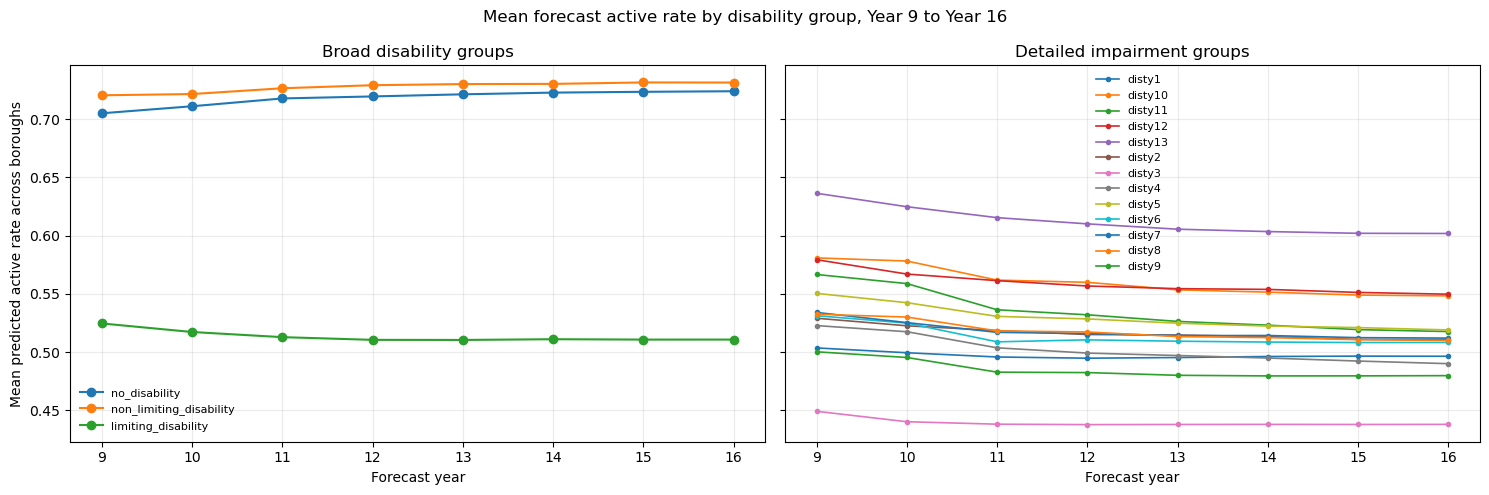

Mean forecast active rate by disability group
(unweighted mean across available boroughs):


,year,disability_group,mean_inactive_rate,mean_fairly_active_rate,mean_active_rate,number_of_boroughs
0,9,disty1,0.3986,0.0977,0.5037,32
1,9,disty10,0.3688,0.0503,0.5809,31
2,9,disty11,0.3610,0.0723,0.5667,31
3,9,disty12,0.3325,0.0881,0.5794,32
4,9,disty13,0.3130,0.0506,0.6364,32
...,...,...,...,...,...,...
123,16,disty8,0.3926,0.0973,0.5101,32
124,16,disty9,0.4233,0.0968,0.4799,32
125,16,limiting_disability,0.3914,0.0978,0.5108,32
126,16,no_disability,0.1803,0.0957,0.7240,32


Change in mean active rate from Year 9 to Year 16:


,disability_group,mean_active_rate_year9,mean_active_rate_year16,change_year9_to_year16
14,no_disability,0.7051,0.7240,0.0189
15,non_limiting_disability,0.7205,0.7314,0.0109
0,disty1,0.5037,0.4965,-0.0072
6,disty3,0.4493,0.4381,-0.0112
13,limiting_disability,0.5247,0.5108,-0.0138
5,disty2,0.5291,0.5108,-0.0184
12,disty9,0.5003,0.4799,-0.0204
10,disty7,0.5341,0.5121,-0.0220
11,disty8,0.5326,0.5101,-0.0225
9,disty6,0.5313,0.5084,-0.0229


In [49]:
import matplotlib.pyplot as plt

group_forecast_summary = (
    dis_overall_forecast
    .groupby(
        ['year', 'disability_group'],
        as_index=False
    )
    .agg(
        mean_inactive_rate=(
            'inactive_rate',
            'mean'
        ),
        mean_fairly_active_rate=(
            'fairly_active_rate',
            'mean'
        ),
        mean_active_rate=(
            'active_rate',
            'mean'
        ),
        number_of_boroughs=(
            'LA_2023',
            'nunique'
        )
    )
)

year9_active = (
    group_forecast_summary[
        group_forecast_summary['year'] == 9
    ][
        ['disability_group', 'mean_active_rate']
    ]
    .rename(
        columns={
            'mean_active_rate':
            'mean_active_rate_year9'
        }
    )
)

year16_active = (
    group_forecast_summary[
        group_forecast_summary['year'] == 16
    ][
        ['disability_group', 'mean_active_rate']
    ]
    .rename(
        columns={
            'mean_active_rate':
            'mean_active_rate_year16'
        }
    )
)

group_active_rate_change = (
    year9_active
    .merge(
        year16_active,
        on='disability_group',
        how='inner'
    )
)

group_active_rate_change[
    'change_year9_to_year16'
] = (
    group_active_rate_change[
        'mean_active_rate_year16'
    ]
    - group_active_rate_change[
        'mean_active_rate_year9'
    ]
)

broad_groups = [
    'no_disability',
    'non_limiting_disability',
    'limiting_disability'
]

detailed_groups = [
    group
    for group in sorted(
        group_forecast_summary[
            'disability_group'
        ].unique()
    )
    if group.startswith('disty')
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    sharey=True
)

for group in broad_groups:
    group_data = group_forecast_summary[
        group_forecast_summary[
            'disability_group'
        ] == group
    ]

    axes[0].plot(
        group_data['year'],
        group_data['mean_active_rate'],
        marker='o',
        label=group
    )

for group in detailed_groups:
    group_data = group_forecast_summary[
        group_forecast_summary[
            'disability_group'
        ] == group
    ]

    axes[1].plot(
        group_data['year'],
        group_data['mean_active_rate'],
        marker='o',
        linewidth=1.2,
        markersize=3,
        label=group
    )

axes[0].set_title(
    'Broad disability groups'
)

axes[1].set_title(
    'Detailed impairment groups'
)

for ax in axes:
    ax.set_xlabel('Forecast year')
    ax.set_xticks(range(9, 17))
    ax.grid(alpha=0.25)
    ax.legend(
        fontsize=8,
        frameon=False
    )

axes[0].set_ylabel(
    'Mean predicted active rate across boroughs'
)

fig.suptitle(
    'Mean forecast active rate by disability group, Year 9 to Year 16'
)

plt.tight_layout()

figure_path = (
    FORECAST_DIR
    / 'figure_forecast_active_rate_by_disability_group.png'
)

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

group_forecast_summary.to_csv(
    FORECAST_DIR
    / 'forecast_mean_active_rate_by_disability_group.csv',
    index=False
)

group_active_rate_change.to_csv(
    FORECAST_DIR
    / 'forecast_active_rate_change_year9_to_year16.csv',
    index=False
)

print(
    'Mean forecast active rate by disability group'
)

print(
    '(unweighted mean across available boroughs):'
)

display(
    group_forecast_summary.round(4)
)

print(
    'Change in mean active rate from Year 9 to Year 16:'
)

display(
    group_active_rate_change
    .sort_values(
        'change_year9_to_year16',
        ascending=False
    )
    .round(4)
)

## 9. Save forecast outputs

In [50]:
dis_overall_forecast.to_csv(FORECAST_DIR / 'forecast_disability_overall_level.csv', index=False)
dis_overall_forecast_naive.to_csv(FORECAST_DIR / 'forecast_disability_overall_level_naive.csv', index=False)
dis_level_forecast.to_csv(FORECAST_DIR / 'forecast_disability_activity_level.csv', index=False)
dis_level_forecast_naive.to_csv(FORECAST_DIR / 'forecast_disability_activity_level_naive.csv', index=False)
months12_forecast.to_csv(FORECAST_DIR / 'forecast_disability_months12.csv', index=False)
months12_forecast_naive.to_csv(FORECAST_DIR / 'forecast_disability_months12_naive.csv', index=False)
days_forecast.to_csv(FORECAST_DIR / 'forecast_disability_days10p60gr.csv', index=False)
days_forecast_naive.to_csv(FORECAST_DIR / 'forecast_disability_days10p60gr_naive.csv', index=False)
top_activity_forecast.to_csv(FORECAST_DIR / 'forecast_top_activity_by_year.csv', index=False)

seed_diagnostics = pd.concat([
    dis_overall_seed_diag.assign(task='disability_overall_level'),
    dis_level_seed_diag.assign(task='disability_activity_level'),
    months12_seed_diag.assign(task='disability_months12'),
    days_seed_diag.assign(task='disability_days10p60gr'),
], ignore_index=True)
seed_diagnostics.to_csv(FORECAST_DIR / 'seed_completeness_diagnostics.csv', index=False)

print('Saved to', FORECAST_DIR)

Saved to C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\forecast_year9_16


In [51]:
warning_summary = pd.DataFrame({
    "task": ["overall", "activity_level", "months12", "days10p60gr", "top_activity"],
    "warning_rate": [
        dis_overall_forecast["historical_reliability_warning"].mean(),
        dis_level_forecast["historical_reliability_warning"].mean(),
        months12_forecast["historical_reliability_warning"].mean(),
        days_forecast["historical_reliability_warning"].mean(),
        top_activity_forecast["historical_reliability_warning"].mean()
    ]
})

print(warning_summary.round(3).to_string(index=False))
warning_summary.to_csv(FORECAST_DIR / "forecast_historical_warning_summary.csv", index=False)

          task  warning_rate
       overall         0.682
activity_level         0.704
      months12         0.735
   days10p60gr         0.735
  top_activity         0.684
